This notebook is intended to perform, evaluate and register all the selection steps involved.
<br>
Here, we are able to work at once with Data and MC processed files with the following recipe:
- Load merged & tagged event/peak-level dataframe.
- __Reconstruction__: use HE scale and perform trigger02 efficiency cut, just for electron-like events.
- __Inclusive__: select events with $nS2=1$.
- __Fiducial__: select events within the fiducial volume.
- __Single-track__: select events with $ncluster=1$.

In every step, we store the dataframes and the event counters. Thus, in this notebook is possible to:
- Update summaries with event counter per run/isotope.
- Plot important variables and perform comparisons.
- Study selection efficiencies at event-level.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import os
import pandas as pd
import scipy
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# --- NOTEBOOK PARAMETERES
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS = ['data', 'mc']

# Extra definitions
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

In [3]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/he_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        input_dir   = common_config['input_dir']
        summary_dir = common_config['summary_dir']
        input_path   = os.path.join(input_dir,   ana_config[ana_type]['processed_file'])
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file'])
        print(f"  Input file path   : {input_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_events  = pd.read_hdf(input_path, key=common_config['evt_key'])
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'groupers'     : ('run_number', 'Run_ID') if ana_type == 'data' else ('isotope', 'Isotope') 
                             , 'he_scale'     : ana_config[ana_type]['he_scale']
                             , 'df_summary'   : df_summary
                             , 'df_processed' : df_events }

        print(f"Loaded successfully.\n")

# ----------------
# GLOBAL CONSTANTS
# ----------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# Geometric boundaries for fiducial volume
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

----- Loading configuration for DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/merged_tagged_runs_LPR_p2_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/summary_LPR_p2_v2_processed.csv
Loaded successfully.

----- Loading configuration for MC
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/merged_tagged_mc_calibration_lpr.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/summary_calibration_lpr_processed.csv
Loaded successfully.



-----

# Reconstructed

Defined as electron-like events with a calibrated energy above $0.5\,\text{MeV}$.

In [4]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_processed']
    df_summ = ANA_INFO[ana_type]['df_summary']
    m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
    b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # Electron-like selection
    if ana_type == 'data':
        df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    elif ana_type == 'mc':  
        pass    # In MC there are only electrons

    # HE scale
    df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
    df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    print(f'{cut_counts}\n')
    df_summ['Reconstructed'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_reco']    = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

run_number
15589    615187
Name: global_event, dtype: int64

isotope
Tl208    98496
Name: global_event, dtype: int64



# Selection

## Inclusive Electrons

Defined as events with $nS2 = 1$

In [5]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_reco']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # nS2 = 1 selection
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    print(f'{cut_counts}\n')
    df_summ['Inclusive'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_inclusive'] = df_temp
    ANA_INFO[ana_type]['df_summary']   = df_summ

run_number
15589    255075
Name: global_event, dtype: int64

isotope
Tl208    61764
Name: global_event, dtype: int64



## Fiducial Electrons

In [6]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_inclusive']
    # df_temp = ANA_INFO[ana_type]['df_strack']
    
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # Fiducial volume selection
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    print(f'{cut_counts}\n')
    df_summ['Fiducial'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_fiducial'] = df_temp
    ANA_INFO[ana_type]['df_summary']  = df_summ

run_number
15589    125951
Name: global_event, dtype: int64

isotope
Tl208    27283
Name: global_event, dtype: int64



## Single Track: or cluster ;)

In [7]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_fiducial']
    # df_temp = ANA_INFO[ana_type]['df_inclusive']
    
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # Single-track selection
    df_temp = df_temp[df_temp['n_cluster'] == 1].copy()

    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    print(f'{cut_counts}\n')
    df_summ['Single_Track'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_strack']  = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

run_number
15589    91117
Name: global_event, dtype: int64

isotope
Tl208    21335
Name: global_event, dtype: int64



# Update Summary

Please generate just __one updated summary__ per version tag.
<br>
That makes me ask: <span style="color:mediumpurple">_are you apply a brand new selection?_</span> If not, just pass ;)

In [9]:
for ana_type in ANA_OPTIONS:

    df_summ = ANA_INFO[ana_type]['df_summary']
    summ_filename = ana_config[ana_type]['summary_file']
    summ_filename = summ_filename.replace('processed', 'updated')

    df_summ.to_csv(os.path.join(common_config['summary_dir'], summ_filename))
    print('Done! Summary updated in:', summ_filename)

Done! Summary updated in: summary_LPR_p2_v2_updated.csv
Done! Summary updated in: summary_calibration_lpr_updated.csv


-----

# Plotting

## Data

### Inclusive/Fiducial

### $E$ distribution

INCLUSIVE: counts = 254997
FIDUCIAL: counts = 125942


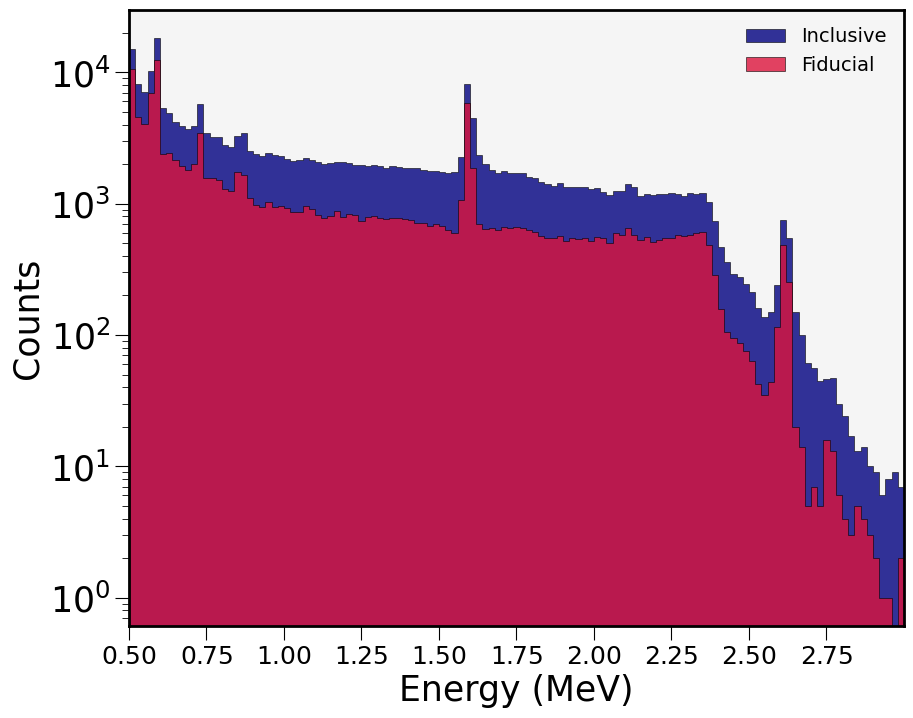

In [13]:
# Global
n_bins = 125
DEP_VALUE = 1.593       # MeV

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['E_final']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 3))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    E_evt = dataframe['E_final']

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    # rate = counts / duration    # in [Hz]
    # print(f"{label.upper()}: counts = {counts.sum()}, corr. time = {duration:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")
    print(f"{label.upper()}: counts = {counts.sum()}")

    # ----- Plotting ----- #
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
# plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=18)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $Z$ Distribution

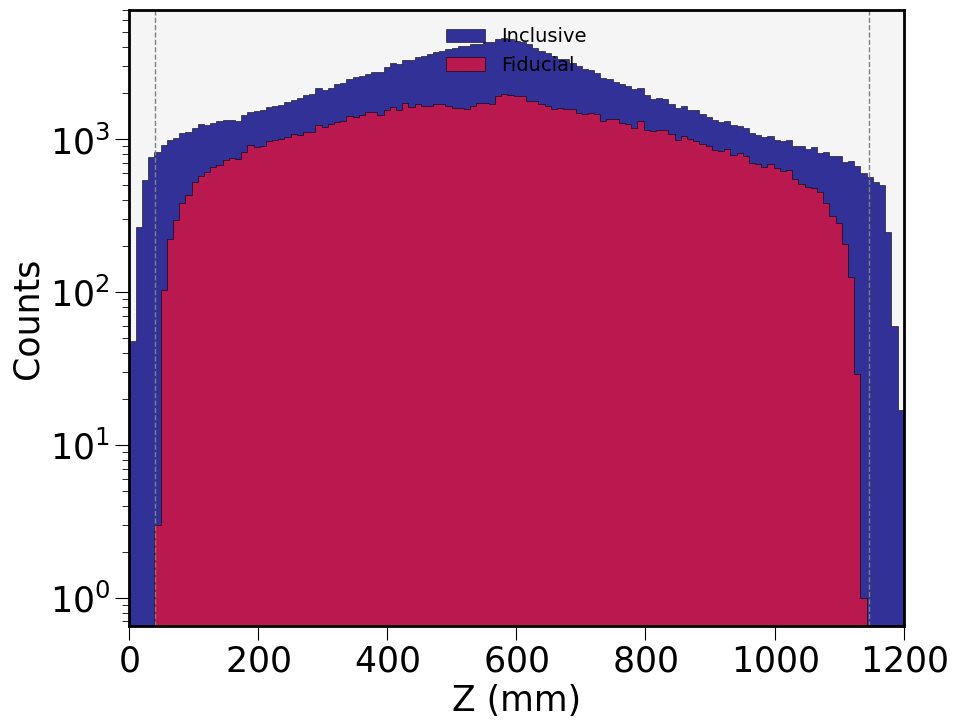

In [16]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['Z_bary']
_, plot_edges = np.histogram(plot_var, bins=n_bins, range=(plot_var.min(), 1200))

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    Z_evt = dataframe['Z_bary']

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    # rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=Z_LOW, c='gray', ls='--', lw=1.0)
plt.axvline(x=Z_UP, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

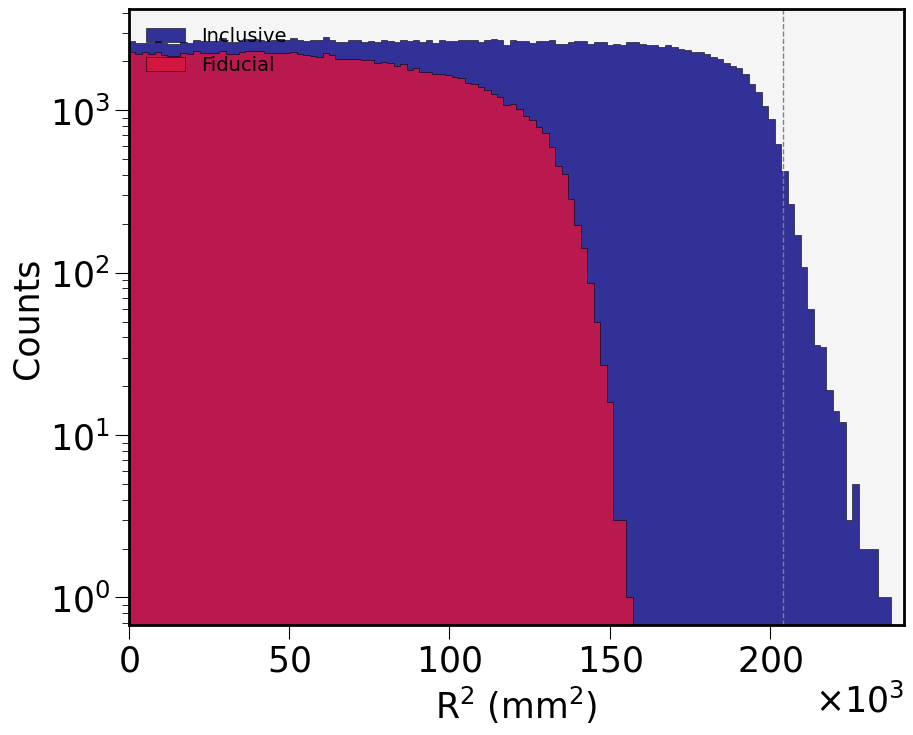

In [19]:
# Global
n_bins = 125

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
plot_var = ANA_INFO['data']['df_inclusive']['X_bary']**2 + ANA_INFO['data']['df_inclusive']['Y_bary']**2
_, plot_edges = np.histogram(plot_var, bins=n_bins)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variable
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    # rate = counts / duration    # in [Hz]

    # ----- Plotting ----- #
    # plt.stairs(rate, bin_edges, label=f'{label}', 
    #            fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=True, color=crudo.pt.comp_colors[i], alpha=0.8,
               ec='black', lw=0.5, zorder=i+1)

# Lines
plt.axvline(x=R_UP**2, c='gray', ls='--', lw=1.0)
plt.axvline(x=crudo.pt.N100_rad**2, c='gray', ls='--', lw=1.0)

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, crudo.pt.N100_rad**2)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left', fontsize=14, facecolor='none')

# plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $XY$ Map

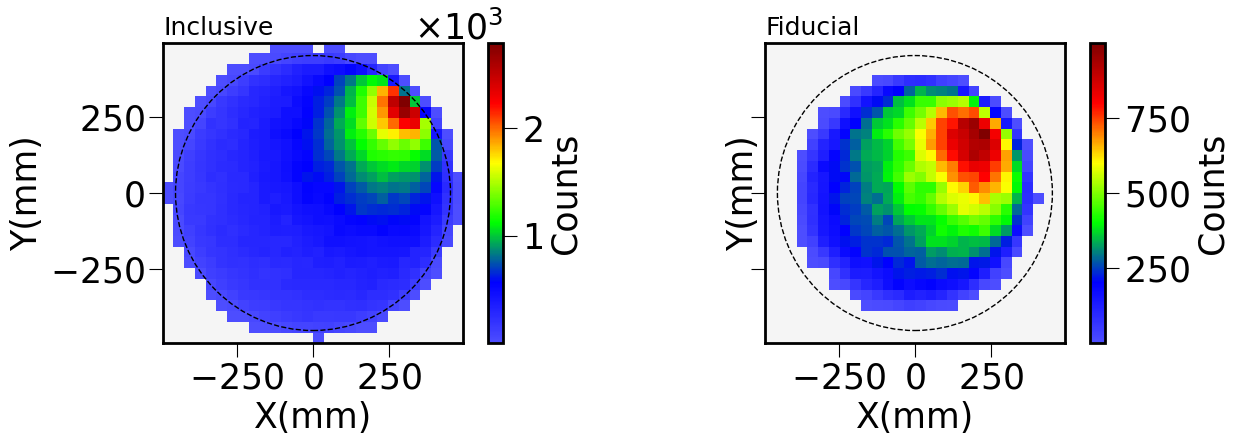

In [23]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for i, label in enumerate(['Inclusive', 'Fiducial']):

    # Dataframe
    if label == 'Inclusive' :   dataframe = ANA_INFO['data']['df_inclusive']
    elif label == 'Fiducial':   dataframe = ANA_INFO['data']['df_fiducial']
    # duration = ANA_INFO['data']['duration']

    # Variables
    X = dataframe['X_bary']
    Y = dataframe['Y_bary']

    # 2D histogram: normalized by corrected DAQ data taking time
    XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, xy_bins=n_bins, pos=True)
    XY_rate            = XY_hit_map # / duration      
    XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)
    # XY_rate            = np.clip(XY_rate, 0, 4e-5)

    # ----- Plotting ----- #
    im = axes[i].pcolormesh(ex, ey, XY_rate.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    cbar.formatter.set_powerlimits((-3, 3))
    axes[i].set_xlabel('X(mm)')
    axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_ylabel('Y(mm)')
    axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].add_patch(crudo.pt.plot_circle(R_UP, linestyle='--'))   # R-lim
    axes[i].set_title(f'{label}', fontsize=18, loc='left')
    axes[i].set_facecolor("whitesmoke")


plt.tight_layout()
plt.show()

-----

# Efficiencies Study

In [8]:
for key in ANA_INFO.keys():
    print(f"{key.upper()}:\n  Keys →", [k for k in ANA_INFO[key].keys()])

DATA:
  Keys → ['groupers', 'he_scale', 'df_summary', 'df_processed', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack']
MC:
  Keys → ['groupers', 'he_scale', 'df_summary', 'df_processed', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack']


## Energy Dependence

The histogram of the __MC reconstructed__ energies defines the binning in the efficiencies comparisons

In [19]:
# Define global limits across both datasets
global_min = min(ANA_INFO['data']['df_reco']['E_final'].min(), ANA_INFO['mc']['df_reco']['E_final'].min())
global_max = max(ANA_INFO['data']['df_reco']['E_final'].max(), ANA_INFO['mc']['df_reco']['E_final'].max())
bin_width = 0.025   # in [MeV]
n_bins = int(np.ceil((global_max - global_min) / bin_width))

# Binning
GLOBAL_EDGES = np.linspace(global_min, global_min + n_bins * bin_width, n_bins + 1)
GLOBAL_EDGES = GLOBAL_EDGES[GLOBAL_EDGES <= 3.0 + bin_width]    # Ensure edges do not exceed 3.0 MeV
GLOBAL_CENTERS = (GLOBAL_EDGES[:-1] + GLOBAL_EDGES[1:]) / 2

print("--- Custom Binning Configuration ---")
print(f"Min/Max Energy : [{global_min:.3f}, {global_max:.3f}] MeV")
print(f"Desired Bin Width   : {bin_width:.4f} MeV")
print(f"Number of Bins      : {n_bins}")
print(f"Actual Edges Range  : [{GLOBAL_EDGES[0]:.3f}, {GLOBAL_EDGES[-1]:.3f}] MeV")
print(f"Generated Bin Width : {GLOBAL_EDGES[1] - GLOBAL_EDGES[0]:.4f} MeV (Exact)")
print("------------------------------------")

--- Custom Binning Configuration ---
Min/Max Energy : [0.500, 26.363] MeV
Desired Bin Width   : 0.0250 MeV
Number of Bins      : 1035
Actual Edges Range  : [0.500, 3.000] MeV
Generated Bin Width : 0.0250 MeV (Exact)
------------------------------------


In [23]:
# Preliminary information
cutflow_stages = [
                    ('df_reco', 'df_inclusive'),
                    ('df_inclusive', 'df_fiducial'),
                    ('df_fiducial', 'df_strack')
                    # ('df_inclusive', 'df_strack'),
                    # ('df_strack', 'df_fiducial')
                ]

# Vectorized efficiency function
vec_efficiency = np.vectorize(crudo.ff.compute_efficiency)

for ana_type in ANA_INFO.keys(): 

    print(f"\n{'-'*5} {ana_type.upper()} {'-'*5}")

    for stage_prior, stage_post in cutflow_stages:

        label = stage_post.split('_')[-1]
        print(f"\nCalculating efficiency for {label} selection:")

        # Energies
        prior_energies = ANA_INFO[ana_type][stage_prior].groupby('global_event')['E_final'].first().reset_index(drop=True)
        post_energies  = ANA_INFO[ana_type][stage_post].groupby('global_event')['E_final'].first().reset_index(drop=True)

        # Histograms
        prior_counts, _ = np.histogram(prior_energies, bins=GLOBAL_EDGES)
        post_counts, _  = np.histogram(post_energies, bins=GLOBAL_EDGES)

        # Ensure post-cut counts are not less than prior counts
        if np.any(post_counts > prior_counts):
            raise ValueError("post counts cannot exceed prior counts. Please check the data for inconsistencies.")

        eff_cv, eff_err = vec_efficiency(prior_counts, post_counts)
        
        # Ensure the dictionary for the label is initialized
        if label not in ANA_INFO[ana_type]:
            ANA_INFO[ana_type][label] = {}

        # Store information
        ANA_INFO[ana_type][label]['eff_cv']  = eff_cv
        ANA_INFO[ana_type][label]['eff_err'] = eff_err

        print(f"  {stage_prior}: {prior_counts.sum()} events")
        print(f"  {stage_post} : {post_counts.sum()} events")


----- DATA -----

Calculating efficiency for inclusive selection:
  df_reco: 612564 events
  df_inclusive : 254997 events

Calculating efficiency for fiducial selection:
  df_inclusive: 254997 events
  df_fiducial : 125942 events

Calculating efficiency for strack selection:
  df_fiducial: 125942 events
  df_strack : 91117 events

----- MC -----

Calculating efficiency for inclusive selection:
  df_reco: 98488 events
  df_inclusive : 61763 events

Calculating efficiency for fiducial selection:
  df_inclusive: 61763 events
  df_fiducial : 27282 events

Calculating efficiency for strack selection:
  df_fiducial: 27282 events
  df_strack : 21334 events



----- INCLUSIVE selection -----
  Data/MC ratio: 0.6314 ± 0.0018
  χ² / ndof = 89.17
  p-value = 0.00

----- FIDUCIAL selection -----
  Data/MC ratio: 1.0541 ± 0.0048
  χ² / ndof = 12.28
  p-value = 0.00

----- STRACK selection -----
  Data/MC ratio: 0.8906 ± 0.0030
  χ² / ndof = 9.01
  p-value = 0.00


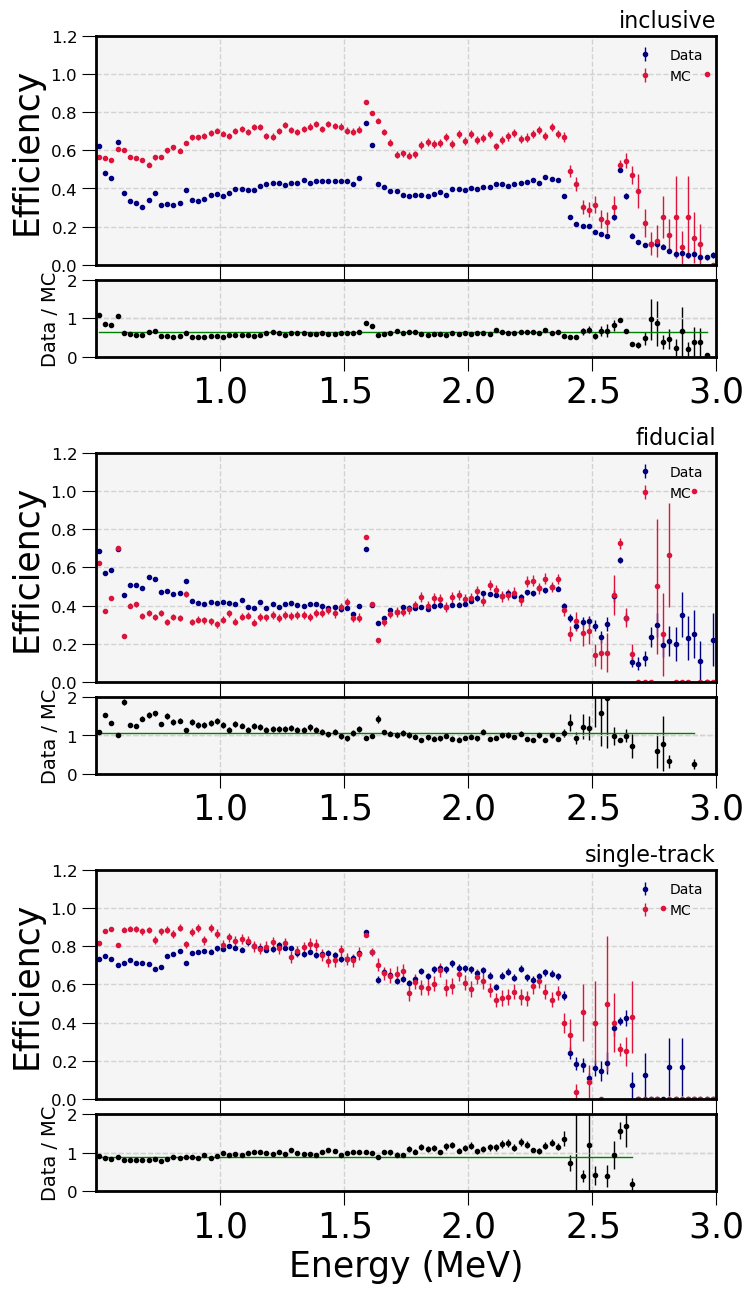

In [26]:
# Preliminary information
selections = [stage_post.split('_')[-1] for _, stage_post in cutflow_stages]

def const_func(x, a):
    return crudo.ff.linear_func(x, 0, a)

# Plotting configuration
fig = plt.figure(figsize=(8, 15))
outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.3)

for row_idx, sel_name in enumerate(selections):

    print(f"\n{'-'*5} {sel_name.upper()} selection {'-'*5}")
    
    # Subdivided plot: main panel (efficiency) and ratio panel (data/MC)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.1)   
    ax_main  = fig.add_subplot(inner_gs[0])
    ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

    # Retrieve data
    data_eff = ANA_INFO['data'][sel_name]['eff_cv'];    data_err = ANA_INFO['data'][sel_name]['eff_err']
    mc_eff   = ANA_INFO['mc'][sel_name]['eff_cv'];      mc_err   = ANA_INFO['mc'][sel_name]['eff_err']

    # ===============================
    # --- MAIN PANEL (Upper Plot) ---
    # ===============================
    # Data
    ax_main.errorbar(GLOBAL_CENTERS, data_eff, yerr=data_err, fmt='o', color='navy', 
                     markersize=3, elinewidth=1.0, label='Data')
    # Simulations
    ax_main.errorbar(GLOBAL_CENTERS, mc_eff, yerr=mc_err, fmt='o', color='crimson',
                     markersize=3, elinewidth=1.0, label='MC')

    # --- Styling --- #
    ax_main.set_title(f"{sel_name if sel_name != 'strack' else 'single-track'}", fontsize=16, loc='right')
    ax_main.set_ylabel("Efficiency")
    ax_main.set_xlim(GLOBAL_EDGES[0], GLOBAL_EDGES[-1])
    ax_main.set_ylim(0, 1.2)
    ax_main.tick_params(axis='y', labelsize=12)
    ax_main.grid(True)
    ax_main.legend(loc='upper right', fontsize=10, facecolor='none')
    ax_main.set_facecolor("whitesmoke")
    # Hide the x-tick labels for the main plot because they are shared with the ratio plot
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # ================================
    # --- RATIO PANEL (Lower Plot) ---
    # ================================
    ratio_cv  = np.zeros_like(data_eff)
    ratio_err = np.zeros_like(data_eff)
    valid_mask = (mc_eff > 0) & (data_eff > 0)      # To avoid divisions by zero
    
    # Ratio: Data / MC
    ratio_cv[valid_mask]  = data_eff[valid_mask] / mc_eff[valid_mask]
    ratio_err[valid_mask] = ratio_cv[valid_mask] * np.sqrt((data_err[valid_mask] / data_eff[valid_mask])**2 
                                                            + (mc_err[valid_mask] / mc_eff[valid_mask])**2)

    # --- Linear Fit --- #
    # Define the cost function + initial guess
    least_squares = LeastSquares(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], ratio_err[valid_mask], const_func)
    init_guess = [ratio_cv[valid_mask].min()]

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"  Data/MC ratio: {popt[0]:.4f} ± {perr[0]:.4f}")

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(GLOBAL_CENTERS[valid_mask]) - m.nfit
    p_value = scipy.stats.chi2.sf(chi2, ndof)
    print(f"  χ² / ndof = {chi2 / ndof:.2f}\n"
          f"  p-value = {p_value:.2f}")

    # --- PLotting --- #
    # Ratio
    ax_ratio.errorbar(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], yerr=ratio_err[valid_mask],
                      fmt='o', color='black', markersize=3, elinewidth=1.0)
    # Fit
    y_fit = const_func(GLOBAL_CENTERS[valid_mask], *popt)
    ax_ratio.plot(GLOBAL_CENTERS[valid_mask], y_fit, color='green', lw=1.0)
    # Reference line
    ax_ratio.axhline(1.0, color='lightgray', ls='--', lw=1.0)

    # --- Styling --- #
    ax_ratio.set_ylabel("Data / MC", fontsize=14)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.tick_params(axis='y', labelsize=12)
    ax_ratio.grid(True)
    ax_ratio.set_facecolor("whitesmoke")
    
    # Only show the X-axis label on the very bottom subplot of the entire figure
    if row_idx == 2:
        ax_ratio.set_xlabel("Energy (MeV)")

plt.show()

## S2 Multiplicity

We notice a larger multiplicity in the $S2$ signal for data than for simulations, indeed:

DATA: total events = 615187, counts = 615187, fraction = 1.00
MC: total events = 98496, counts = 98496, fraction = 1.00


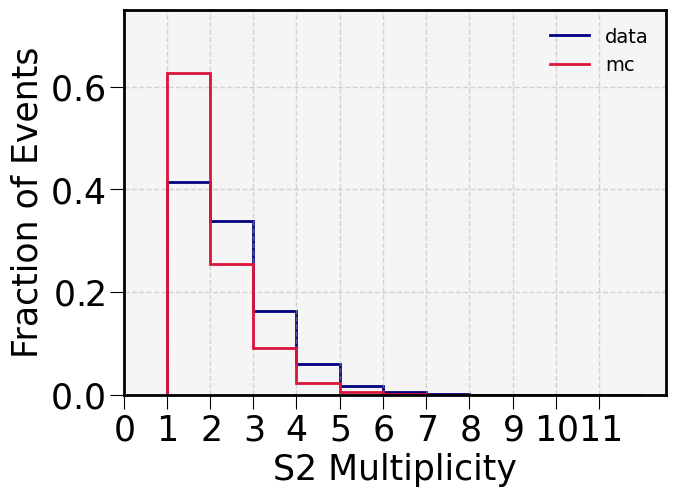

In [12]:
# Binning
plot_var = ANA_INFO['data']['df_reco']['nS2']
plot_edges = np.arange(plot_var.min(), plot_var.max() + 2, 1)

plt.figure(figsize=(7, 5))

for i, ana_type in enumerate(ANA_INFO.keys()):

    # Dataframe
    dataframe = ANA_INFO[ana_type]['df_reco']
    tot_evts = dataframe['global_event'].nunique()

    # Variable
    nS2 = dataframe.groupby('global_event')['nS2'].first()

    # Histogram
    counts, _ = np.histogram(nS2, bins=plot_edges)
    frac = counts / tot_evts
    print(f"{ana_type.upper()}: total events = {tot_evts}, counts = {counts.sum()}, fraction = {frac.sum():.2f}")

    # --- Plotting --- #
    plt.stairs(frac, plot_edges, label=f'{ana_type}', 
               fill=False, ec=crudo.pt.comp_colors[i],
               lw=2.0, zorder=i+1)

# --- Styling --- #
plt.xlabel('S2 Multiplicity')
plt.xticks(np.arange(0, plot_edges[-1], 1))
plt.ylabel('Fraction of Events')
plt.ylim(0.0, 0.75)
# plt.yscale('log')
plt.legend(loc='upper right', fontsize=14, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

### $nS2=2$

How does it look this population?

In [ ]:
S2_MULTI_INFO = {opt:{} for opt in ANA_OPTIONS}

for ana_type in ANA_OPTIONS:

    # Original dataframe
    df_temp = ANA_INFO[ana_type]['df_reco']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # nS2 = 2 selection
    df_temp = df_temp[df_temp['nS2'] == 2].copy()

    # Estimate the energy contribution of each S2 to the total event energy
    df_evt = df_temp.groupby('global_event').agg( E_final = ('E_final', 'first')
                                                , S2e_sum = ('S2e', 'sum')
                                                , S2e_max = ('S2e', 'max')
                                                , S2e_min = ('S2e', 'min')
                                                , S2t_max = ('S2t', 'max')
                                                , S2t_min = ('S2t', 'min') ).reset_index()

    df_evt['S2e_max_mev'] = (df_evt['S2e_max'] / df_evt['S2e_sum']) * df_evt['E_final']
    df_evt['S2e_min_mev'] = (df_evt['S2e_min'] / df_evt['S2e_sum']) * df_evt['E_final']

    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique();     print(f'{cut_counts}\n')
    S2_MULTI_INFO[ana_type]['df_two_s2'] = df_evt

run_number
15589    208208
Name: global_event, dtype: int64

isotope
Tl208    25159
Name: global_event, dtype: int64



In [47]:
S2_MULTI_INFO['data']['df_two_s2']

,global_event,E_final,S2e_sum,S2e_max,S2e_min,S2t_max,S2t_min,S2e_max_mev,S2e_min_mev
0,0,1.172228,195517.062500,150070.453125,45446.609375,2143500.500,1.417490e+06,0.899752,0.272477
1,5,1.654985,300156.578125,175166.187500,124990.390625,1791484.750,1.410473e+06,0.965821,0.689164
2,7,0.706686,137370.881836,129556.906250,7813.975586,1614497.250,1.408490e+06,0.666488,0.040198
3,19,1.580029,289362.478516,265808.718750,23553.759766,1686486.625,1.404485e+06,1.451417,0.128612
4,24,2.854532,562174.671875,375276.031250,186898.640625,1965485.250,1.421487e+06,1.905524,0.949008
...,...,...,...,...,...,...,...,...,...
208203,792260,0.818479,169212.761719,121040.992188,48171.769531,1405490.125,7.984964e+05,0.585473,0.233006
208204,792263,1.282665,253903.828125,144336.218750,109567.609375,1722490.375,1.411487e+06,0.729154,0.553511
208205,792266,0.581068,119671.164062,93322.546875,26348.617188,1543494.625,1.406493e+06,0.453132,0.127937
208206,792271,0.599492,109136.484375,71360.828125,37775.656250,1908485.375,1.407478e+06,0.391989,0.207504



----- DATA -----
Selected Events: 39304
Range of ΔS2e = [0.00, 2.37] MeV
Range of ΔS2t = [26.98, 1570.98] μs

----- MC -----
Selected Events: 3651
Range of ΔS2e = [0.00, 2.37] MeV
Range of ΔS2t = [0.00, 1239.97] μs


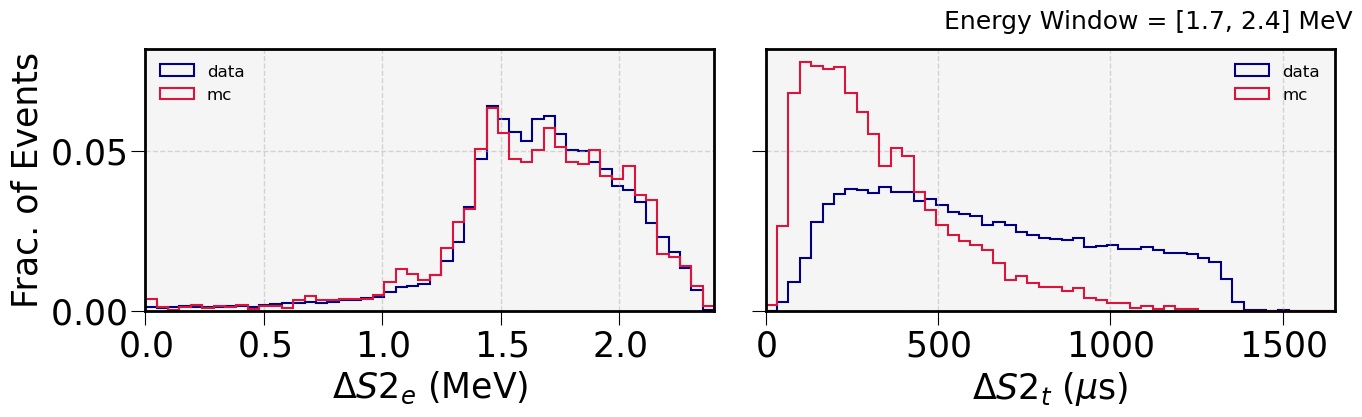

In [59]:
# Global
ENERGY_LIMITS = [1.70, 2.40]  # in [MeV]

# Binning
n_bins = 50
e_edges = np.linspace(0, ENERGY_LIMITS[1], n_bins + 1)
t_edges = np.linspace(0, 1650, n_bins + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, ana_type in enumerate(S2_MULTI_INFO.keys()):

    print(f"\n{'-'*5} {ana_type.upper()} {'-'*5}")

    df = S2_MULTI_INFO[ana_type]['df_two_s2']
    df = df[(df['E_final'] >= ENERGY_LIMITS[0]) & (df['E_final'] <= ENERGY_LIMITS[1])].copy()

    # Compute main information
    n_evts = df['global_event'].nunique()
    dS2e = df['S2e_max_mev'] - df['S2e_min_mev']    # In [MeV]
    dS2t = (df['S2t_max'] - df['S2t_min']) / 1e3    # In [μs]

    S2_MULTI_INFO[ana_type]['n_evts'] = n_evts
    S2_MULTI_INFO[ana_type]['diffs'] = {'dS2e': dS2e, 'dS2t': dS2t}
    print(f"Selected Events: {n_evts}")
    print(f"Range of ΔS2e = [{dS2e.min():.2f}, {dS2e.max():.2f}] MeV")
    print(f"Range of ΔS2t = [{dS2t.min():.2f}, {dS2t.max():.2f}] μs")

    if n_evts == 0:
        print("Warning: No events survived selection. Skipping plotting.")
        continue
    weights = np.ones_like(dS2e) / n_evts    # Normalize to fraction of events

    # S2e differences
    axes[0].hist(dS2e, bins=e_edges, weights=weights, histtype='step',
                 color=crudo.pt.comp_colors[i], lw=1.5, label=f'{ana_type}', zorder=i+1)

    # S2t differences
    axes[1].hist(dS2t, bins=t_edges, weights=weights, histtype='step',
                 color=crudo.pt.comp_colors[i], lw=1.5, label=f'{ana_type}', zorder=i+1)
    

# --- Styling --- #
axes[0].set_xlabel(r'$\Delta S2_{e}$ (MeV)')
axes[0].set_ylabel('Frac. of Events')
# axes[0].set_yscale('log')
axes[0].set_xlim(0, ENERGY_LIMITS[1])
axes[0].legend(loc='upper left', fontsize=12, facecolor='none')
axes[0].grid(True)
axes[0].set_facecolor("whitesmoke")

axes[1].set_xlabel(r'$\Delta S2_{t}$ ($\mu$s)')
# axes[1].set_ylabel('Frac. of Events')
axes[1].set_xlim(0, t_edges[-1])
axes[1].legend(loc='upper right', fontsize=12, facecolor='none')
axes[1].grid(True)
axes[1].set_facecolor("whitesmoke")

plt.suptitle(f"Energy Window = [{ENERGY_LIMITS[0]}, {ENERGY_LIMITS[1]}] MeV", x=0.84, y=0.87, fontsize=18)
plt.tight_layout()
plt.show()


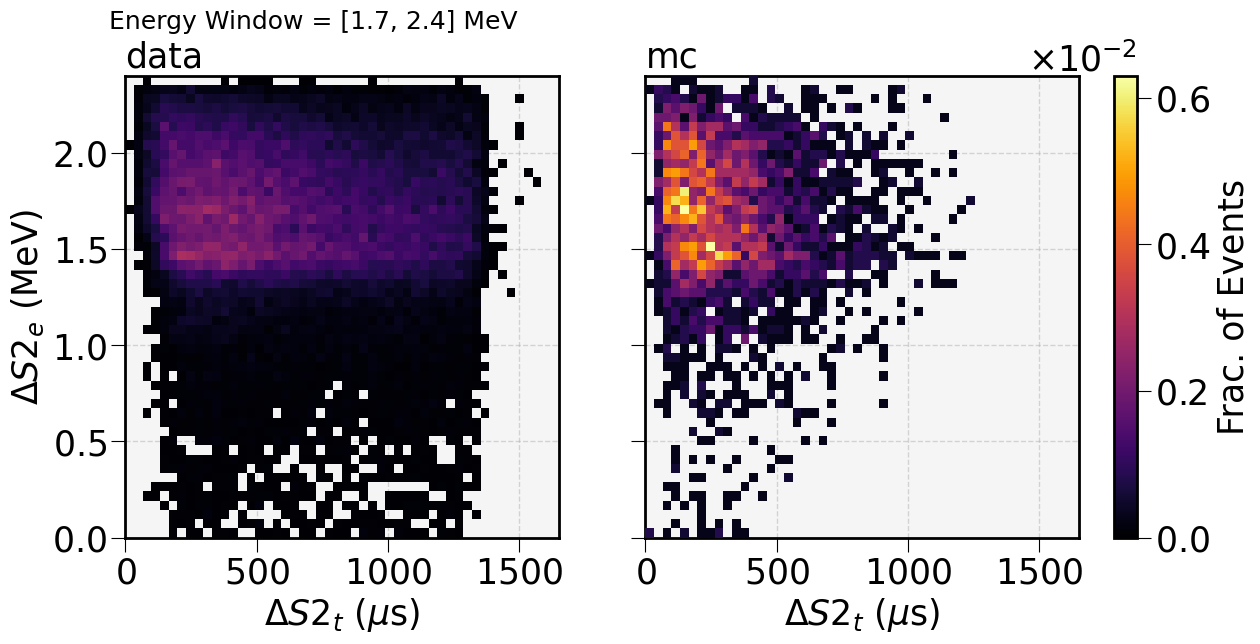

In [60]:
fracs = {}

for i, ana_type in enumerate(S2_MULTI_INFO.keys()):

    n_evts = S2_MULTI_INFO[ana_type]['n_evts']
    dS2t = S2_MULTI_INFO[ana_type]['diffs']['dS2t']
    dS2e = S2_MULTI_INFO[ana_type]['diffs']['dS2e']
    
    hist_2d, _, _   = np.histogram2d(dS2t, dS2e, bins=[t_edges, e_edges])
    fracs[ana_type] = hist_2d / n_evts

# Limits for shared colorbars
global_vmin = 0
global_vmax = max(fracs['data'].max(), fracs['mc'].max())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
im_plot = None

for i, ana_type in enumerate(ANA_INFO.keys()):

    hist_frac = fracs[ana_type]
    hist_frac = np.ma.masked_where(hist_frac == 0, hist_frac)
    
    im_plot = axes[i].pcolormesh(t_edges, e_edges, hist_frac.T, cmap='inferno',
                                 shading='auto', vmin=global_vmin, vmax=global_vmax, zorder=3)
    
    # Styling
    axes[i].set_title(f'{ana_type}', fontsize=25, loc='left')
    axes[i].set_xlabel(r'$\Delta S2_{t}$ ($\mu$s)')
    axes[i].set_facecolor("whitesmoke")
    axes[i].grid(True)

axes[0].set_ylabel(r'$\Delta S2_{e}$ (MeV)')

cbar = fig.colorbar(
                        im_plot, 
                        ax=axes.ravel().tolist(), 
                        label='Frac. of Events', 
                        shrink=1.0, 
                        pad=0.03
                    )
cbar.formatter.set_powerlimits((-2, -2))
cbar.update_ticks()

plt.suptitle(f"Energy Window = [{ENERGY_LIMITS[0]}, {ENERGY_LIMITS[1]}] MeV", x=0.25, y=0.99, fontsize=18)
# plt.tight_layout()
plt.show()

## Event Lengths: or how is the fiducial selection affected?

In [61]:
TRACKS_INFO = {opt:{} for opt in ANA_OPTIONS }

for ana_type in ANA_OPTIONS:

    # Original dataframe
    df_temp = ANA_INFO[ana_type]['df_inclusive']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    if df_temp['nS2'].max() > 1: print(f"Mmm, it seems that there are events with nS2 > 1 in the inclusive selection for {ana_type}...")

    # Orthogonal projection spans of the bounding box of the event
    df_temp['span_X'] = df_temp['X_max'] - df_temp['X_min']
    df_temp['span_Y'] = df_temp['Y_max'] - df_temp['Y_min']
    df_temp['span_Z'] = df_temp['Z_max'] - df_temp['Z_min']

    df_temp['bbox_diag_XY'] = np.sqrt(df_temp['span_X']**2 + df_temp['span_Y']**2)
    df_temp['bbox_diag_3D'] = np.sqrt((df_temp['bbox_diag_XY'])**2 + (df_temp['span_Z'])**2)
    
    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique();     print(f'{cut_counts}\n')
    TRACKS_INFO[ana_type]['df_inclusive'] = df_temp

run_number
15589    255075
Name: global_event, dtype: int64

isotope
Tl208    61764
Name: global_event, dtype: int64



In [62]:
n_bins = len(global_edges) - 1
var_mapping = { 'ave_diag_XY' : 'bbox_diag_XY'
              , 'ave_span_Z'  : 'span_Z'
              , 'ave_diag_3D' : 'bbox_diag_3D' }

for ana_type in TRACKS_INFO.keys():

    print(f"Processing {ana_type.upper()}")

    df_temp = TRACKS_INFO[ana_type]['df_inclusive']

    # Initialize arrays to store info per energy bin
    binned_results = {
                        key: { 'cv'  : np.full(n_bins, np.nan, dtype=float),
                               'err' : np.full(n_bins, np.nan, dtype=float) }
                        for key in var_mapping.keys()
                     }

    # --- Main Loop --- #
    for i in range(n_bins):

        lower_edge = GLOBAL_EDGES[i]
        upper_edge = GLOBAL_EDGES[i + 1]

        # Select events within the energy bin
        df_bin = df_temp[(df_temp['E_final'] >= lower_edge) & (df_temp['E_final'] < upper_edge)].copy()

        if not df_bin.empty:
            for store_key, col_name in var_mapping.items():
                binned_results[store_key]['cv'][i]  = df_bin[col_name].mean()
                binned_results[store_key]['err'][i] = df_bin[col_name].sem()

    # Store results
    for store_key in var_mapping.keys():
        TRACKS_INFO[ana_type][store_key] = binned_results[store_key]

Processing DATA
Processing MC


Generating Ave. 3D Extension Plot
Generating Ave. Z Extension Plot
Generating Ave. XY Extension Plot


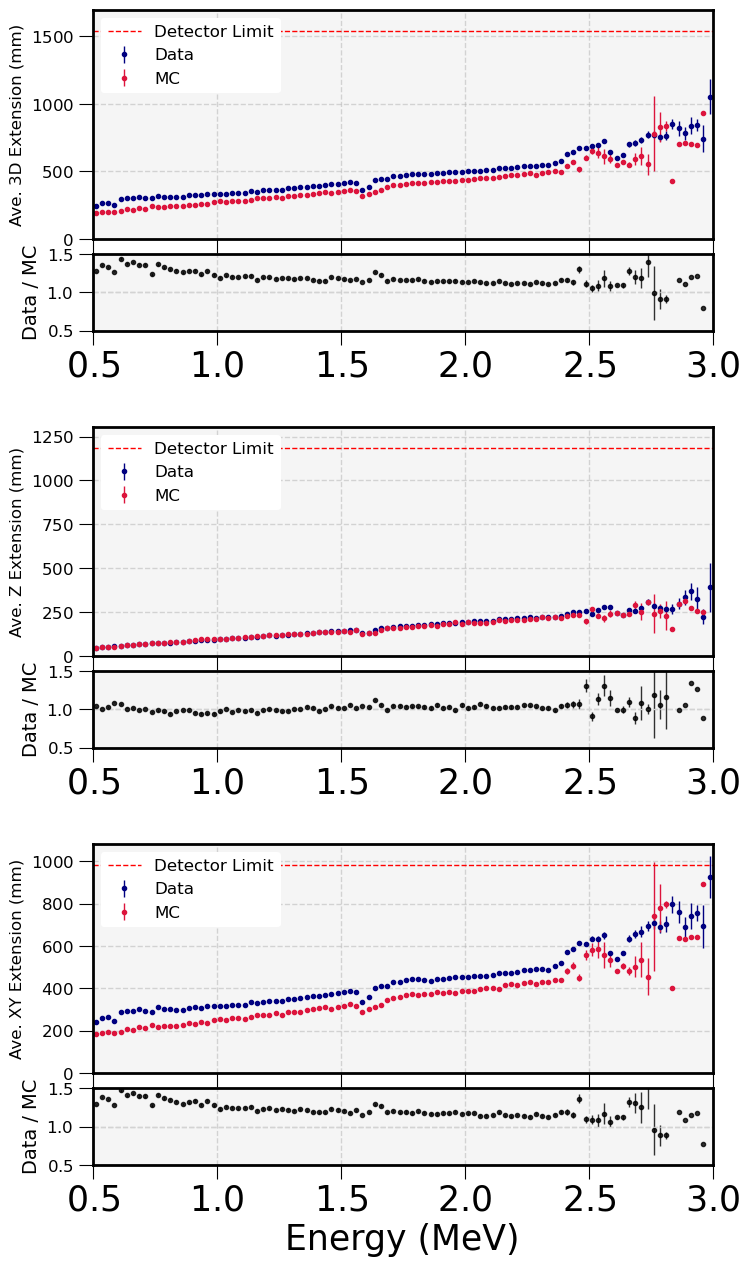

In [63]:
# Plotting configuration
fig = plt.figure(figsize=(8, 15))
outer_gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.3)

for row_idx, distance in enumerate(['ave_diag_3D', 'ave_span_Z', 'ave_diag_XY']):

    if distance == 'ave_diag_3D'   : label = "Ave. 3D Extension";   det_limit = np.sqrt( (2*crudo.pt.N100_rad)**2 + crudo.pt.N100_hei**2 )
    elif distance == 'ave_span_Z'  : label = "Ave. Z Extension";    det_limit = crudo.pt.N100_hei
    elif distance == 'ave_diag_XY' : label = "Ave. XY Extension";   det_limit = 2*crudo.pt.N100_rad

    print(f"Generating {label} Plot")
    
    # Subdivided plot: main panel and ratio panel (data/MC)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.1)   
    ax_main  = fig.add_subplot(inner_gs[0])
    ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

    # Data
    data_cv = TRACKS_INFO['data'][distance]['cv'];      data_err = TRACKS_INFO['data'][distance]['err']
    mc_cv   = TRACKS_INFO['mc'][distance]['cv'];        mc_err   = TRACKS_INFO['mc'][distance]['err']

    # ===============================
    # --- MAIN PANEL (Upper Plot) ---
    # ===============================
    # Data
    ax_main.errorbar(GLOBAL_CENTERS, data_cv, yerr=data_err, fmt='o', color='navy', 
                     markersize=3, elinewidth=1.0, label='Data')
    # Simulations
    ax_main.errorbar(GLOBAL_CENTERS, mc_cv, yerr=mc_err, fmt='o', color='crimson',
                     markersize=3, elinewidth=1.0, label='MC')
    # Detector limits
    ax_main.axhline(det_limit, color='red', ls='--', lw=1.0, label='Detector Limit')

    # --- Styling --- #
    ax_main.set_ylabel(f"{label} (mm)", fontsize=12)
    ax_main.set_xlim(0.5, 3.0)
    ax_main.set_ylim(0, det_limit*1.1)
    ax_main.tick_params(axis='y', labelsize=12)
    ax_main.grid(True)
    ax_main.legend(loc='upper left', fontsize=12, facecolor='white', framealpha=1.0)
    ax_main.set_facecolor("whitesmoke")
    # Hide the x-tick labels for the main plot because they are shared with the ratio plot
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # ================================
    # --- RATIO PANEL (Lower Plot) ---
    # ================================
    ratio_cv = np.zeros_like(data_cv);  ratio_err = np.zeros_like(data_cv)
    valid_mask = (mc_cv > 0) & (data_cv > 0)      # To avoid divisions by zero
    
    # Ratio: Data / MC
    ratio_cv[valid_mask]  = data_cv[valid_mask] / mc_cv[valid_mask]
    ratio_err[valid_mask] = ratio_cv[valid_mask] * np.sqrt((data_err[valid_mask] / data_cv[valid_mask])**2 
                                                            + (mc_err[valid_mask] / mc_cv[valid_mask])**2)

    ax_ratio.errorbar(bin_centers[valid_mask], ratio_cv[valid_mask], yerr=ratio_err[valid_mask],
                      fmt='o', color='black', markersize=3, elinewidth=1.0, alpha=0.8)
    ax_ratio.axhline(1.0, color='lightgray', ls='--', lw=1.0)

    # --- Styling --- #
    ax_ratio.set_ylabel("Data / MC", fontsize=14)
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.tick_params(axis='y', labelsize=12)
    ax_ratio.grid(True)
    ax_ratio.set_facecolor("whitesmoke")
    
    # Only show the X-axis label on the very bottom subplot of the entire figure
    if row_idx == 2:
        ax_ratio.set_xlabel("Energy (MeV)")

plt.show()

### Radial Fiducial Volume

Apparently, we cannot explain the current efficiency plot of the fiducial selection just by event extension.
<br>
Shorter extension in the $XY$ plane for MC, would imply a better fiducial efficiency across the energy spectrum, which is not the case.
<br>
How would change this if the fiducial volume were entirely radial?

In [64]:
for ana_type in ANA_OPTIONS:

    # Original dataframe
    df_temp = TRACKS_INFO[ana_type]['df_inclusive'].drop(columns=['region'])    # We will tag events in the detector again
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # Just keep events with nS1 = 1, we completely avoid nS1 = 0 effects
    df_temp = df_temp[df_temp['nS1'] == 1].copy()

    # Tagging in a radial fiducial volume
    df_temp['region'] = np.where(df_temp['R_max'] <= R_UP, 'fiducial', 'unclassified')
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()
    
    # Update
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique();     print(f'{cut_counts}\n')
    TRACKS_INFO[ana_type]['df_fiducial'] = df_temp

run_number
15589    131854
Name: global_event, dtype: int64

isotope
Tl208    29116
Name: global_event, dtype: int64



#### Efficiency Plot

In [65]:
# Preliminary information
cutflow_stages = [('df_inclusive', 'df_fiducial')]

# Vectorized efficiency function
vec_efficiency = np.vectorize(crudo.ff.compute_efficiency)

for ana_type in TRACKS_INFO.keys(): 

    print(f"Processing {ana_type.upper()}:")

    for stage_prior, stage_post in cutflow_stages:

        label = stage_post.split('_')[-1]
        print(f"  Calculating efficiency for {label} selection...")

        # Energies
        prior_energies = TRACKS_INFO[ana_type][stage_prior].groupby('global_event')['E_final'].first().reset_index(drop=True)
        post_energies  = TRACKS_INFO[ana_type][stage_post].groupby('global_event')['E_final'].first().reset_index(drop=True)

        # Histograms
        prior_counts, _ = np.histogram(prior_energies, bins=GLOBAL_EDGES)
        post_counts, _  = np.histogram(post_energies, bins=GLOBAL_EDGES)

        # Ensure post-cut counts are not less than prior counts
        if np.any(post_counts > prior_counts):
            raise ValueError("post counts cannot exceed prior counts. Please check the data for inconsistencies.")

        eff_cv, eff_err = vec_efficiency(prior_counts, post_counts)
        
        # Ensure the dictionary for the label is initialized
        if label not in TRACKS_INFO[ana_type]:
            TRACKS_INFO[ana_type][label] = {}

        # Store information
        TRACKS_INFO[ana_type][label]['eff_cv']  = eff_cv
        TRACKS_INFO[ana_type][label]['eff_err'] = eff_err

        print(f"    {stage_prior}: {prior_counts.sum()} events")
        print(f"    {stage_post} : {post_counts.sum()} events\n")

Processing DATA:
  Calculating efficiency for fiducial selection...
    df_inclusive: 254997 events
    df_fiducial : 131842 events

Processing MC:
  Calculating efficiency for fiducial selection...
    df_inclusive: 61763 events
    df_fiducial : 29115 events



FIDUCIAL selection:
  Data/MC ratio: 1.0376 ± 0.0044
  χ² / ndof = 12.51
  p-value = 0.00



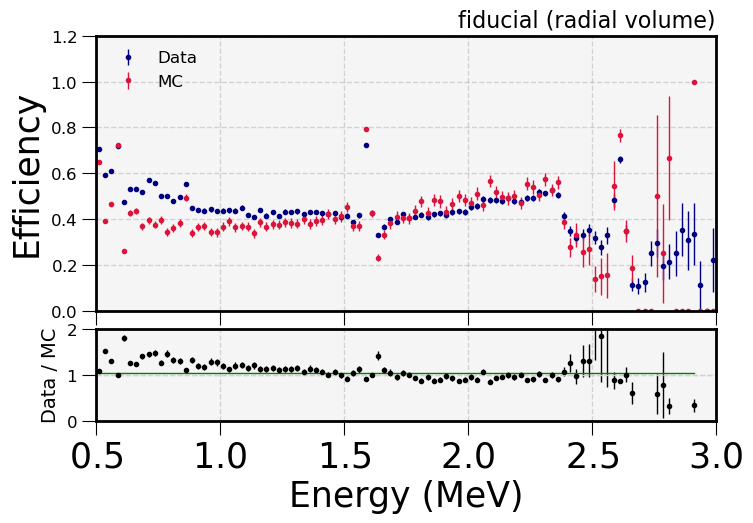

In [66]:
# Preliminary information
selections = [stage_post.split('_')[-1] for _, stage_post in cutflow_stages]

def const_func(x, a):
    return crudo.ff.linear_func(x, 0, a)

# Plotting configuration
fig = plt.figure(figsize=(8, 5*len(cutflow_stages)))
outer_gs = gridspec.GridSpec(len(cutflow_stages), 1, figure=fig, hspace=0.3)

for row_idx, sel_name in enumerate(selections):

    print(f"{sel_name.upper()} selection:")
    
    # Subdivided plot: main panel (efficiency) and ratio panel (data/MC)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.1)   
    ax_main  = fig.add_subplot(inner_gs[0])
    ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

    # Retrieve information
    data_eff = TRACKS_INFO['data'][sel_name]['eff_cv'];     data_err = TRACKS_INFO['data'][sel_name]['eff_err']
    mc_eff   = TRACKS_INFO['mc'][sel_name]['eff_cv'];       mc_err   = TRACKS_INFO['mc'][sel_name]['eff_err']

    # ===============================
    # --- MAIN PANEL (Upper Plot) ---
    # ===============================
    # Data
    ax_main.errorbar(GLOBAL_CENTERS, data_eff, yerr=data_err, fmt='o', color='navy', 
                     markersize=3, elinewidth=1.0, label='Data')
    # Simulations
    ax_main.errorbar(GLOBAL_CENTERS, mc_eff, yerr=mc_err, fmt='o', color='crimson',
                     markersize=3, elinewidth=1.0, label='MC')

    # --- Styling --- #
    ax_main.set_title(f"{sel_name if sel_name != 'strack' else 'single-track'} (radial volume)", fontsize=16, loc='right')
    ax_main.set_ylabel("Efficiency")
    ax_main.set_xlim(0.5, 3.0)
    ax_main.set_ylim(0, 1.2)
    ax_main.tick_params(axis='y', labelsize=12)
    ax_main.grid(True)
    ax_main.legend(loc='upper left', fontsize=12, facecolor='none')
    ax_main.set_facecolor("whitesmoke")
    # Hide the x-tick labels for the main plot because they are shared with the ratio plot
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # ================================
    # --- RATIO PANEL (Lower Plot) ---
    # ================================
    ratio_cv, ratio_err  = np.zeros_like(data_eff), np.zeros_like(data_eff)
    valid_mask = (mc_eff > 0) & (data_eff > 0)      # To avoid divisions by zero
    
    # Ratio: Data / MC
    ratio_cv[valid_mask]  = data_eff[valid_mask] / mc_eff[valid_mask]
    ratio_err[valid_mask] = ratio_cv[valid_mask] * np.sqrt((data_err[valid_mask] / data_eff[valid_mask])**2 
                                                            + (mc_err[valid_mask] / mc_eff[valid_mask])**2)

    # --- Linear Fit --- #
    # Define the cost function + initial guess
    least_squares = LeastSquares(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], ratio_err[valid_mask], const_func)
    init_guess = [ratio_cv[valid_mask].min()]

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"  Data/MC ratio: {popt[0]:.4f} ± {perr[0]:.4f}")

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(GLOBAL_CENTERS[valid_mask]) - m.nfit
    p_value = scipy.stats.chi2.sf(chi2, ndof)
    print(f"  χ² / ndof = {chi2 / ndof:.2f}")
    print(f"  p-value = {p_value:.2f}\n")

    # --- PLotting --- #
    # Ratio
    ax_ratio.errorbar(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], yerr=ratio_err[valid_mask],
                      fmt='o', color='black', markersize=3, elinewidth=1.0)
    # Fit
    y_fit = const_func(GLOBAL_CENTERS[valid_mask], *popt)
    ax_ratio.plot(GLOBAL_CENTERS[valid_mask], y_fit, color='green', lw=1.0)
    # Reference line
    ax_ratio.axhline(1.0, color='lightgray', ls='--', lw=1.0)

    # --- Styling --- #
    ax_ratio.set_ylabel("Data / MC", fontsize=14)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.tick_params(axis='y', labelsize=12)
    ax_ratio.grid(True)
    ax_ratio.set_facecolor("whitesmoke")
    
    # Only show the X-axis label on the very bottom subplot of the entire figure
    if row_idx == len(cutflow_stages) - 1:
        ax_ratio.set_xlabel("Energy (MeV)")

plt.show()

It does not change nothing!
<br>
What if is something related with the radial distribution of the events?

### Radial Distribution of Events

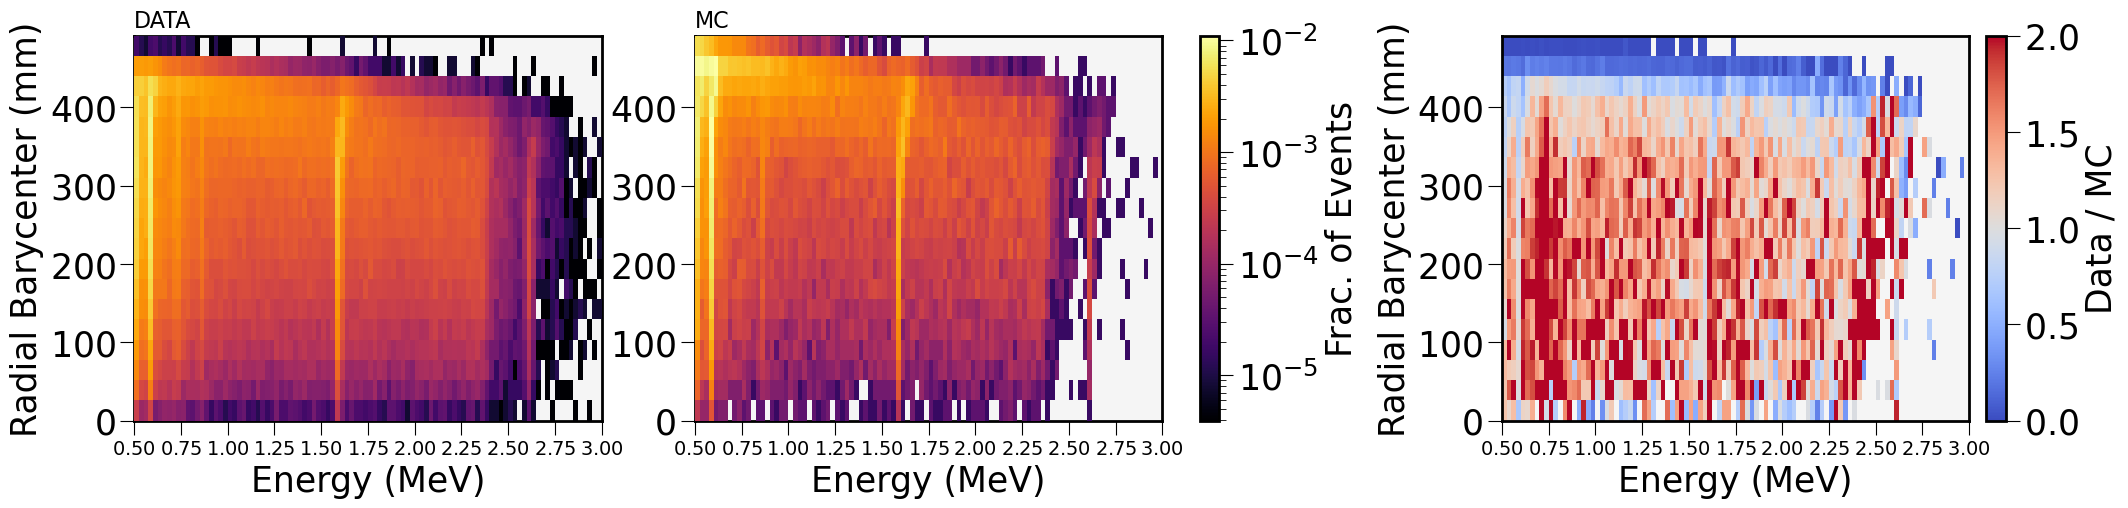

In [72]:
# Binning
r_edges = np.linspace(0, crudo.pt.N100_rad, 20)
n_bins = len(GLOBAL_EDGES) - 1

# Store 2D histogram information
histograms = {}

# Global value for syncing color scales across data and MC
vmin, vmax = 1.0, 0.0
fig, axes = plt.subplots(1, 3, figsize=(25, 5))

# ----- Histogram and Median Calculation ----- #
for ana_type in TRACKS_INFO.keys():

    df_temp = TRACKS_INFO[ana_type]['df_inclusive'] 
    R_bary  = np.sqrt(df_temp['X_bary']**2 + df_temp['Y_bary']**2)

    # Histogram
    hist, _, _ = np.histogram2d(df_temp['E_final'], R_bary, bins=[GLOBAL_EDGES, r_edges])
    hist_fraction = hist / hist.sum()       # Normalize by total events
    histograms[ana_type] = hist_fraction

    # Track of global min/max
    masked_fracs = hist_fraction[hist_fraction > 0]
    if len(masked_fracs) > 0:
        vmin = min(vmin, masked_fracs.min())
        vmax = max(vmax, masked_fracs.max())

    # --- Median Values + Error --- #
    medians = np.full(n_bins, np.nan)
    errors  = np.full(n_bins, np.nan)

    for idx in range(n_bins):

        bin_mask = (df_temp['E_final'] >= GLOBAL_EDGES[idx]) & (df_temp['E_final'] < GLOBAL_EDGES[idx + 1])
        r_in_bin = R_bary[bin_mask]
        n_events = len(r_in_bin)

        if n_events > 0:
            medians[idx] = np.median(r_in_bin)            
            std_dev = np.std(r_in_bin, ddof=1) if n_events > 1 else 0.0
            errors[idx] = 1.2533 * (std_dev / np.sqrt(n_events))

    # Store
    TRACKS_INFO[ana_type]['rad_median'] = { 'cv'  : medians,
                                            'err' : errors   }

# ----- Plotting ----- #
# Data & MC
for i, ana_type in enumerate(TRACKS_INFO.keys()):

    hist = np.ma.masked_where(histograms[ana_type] == 0, histograms[ana_type])
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    
    im = axes[i].pcolormesh(GLOBAL_EDGES, r_edges, hist.T, cmap='inferno', norm=norm, shading='auto', zorder=3)
    axes[i].set_title(f"{ana_type.upper()}", fontsize=16, loc='left')
    axes[i].set_facecolor("whitesmoke")
# Shared colorbar
cbar_shared = fig.colorbar(im, ax=axes[:2], label='Frac. of Events', shrink=1.0, pad=0.03)

# Data / MC Ratio
ratio = np.divide( histograms['data'], histograms['mc'],
                   out=np.nan * np.zeros_like(histograms['data']), where=histograms['mc'] > 0 )                 
ratio = np.ma.masked_invalid(ratio)                 # Remove NaNs
ratio_norm = mcolors.Normalize(vmin=0, vmax=2)  # Use a divergent colormap centered at 1.0 (good agreement = white)

im_ratio = axes[2].pcolormesh(GLOBAL_EDGES, r_edges, ratio.T, cmap='coolwarm', norm=ratio_norm, shading='auto')
axes[2].set_facecolor("whitesmoke")
cbar_ratio = fig.colorbar(im_ratio, ax=axes[2], label='Data / MC', shrink=1.0, pad=0.03)

# --- Styling --- #
for ax in axes:
    ax.set_xlabel("Energy (MeV)")
    ax.set_xlim(GLOBAL_EDGES[0], GLOBAL_EDGES[-1])
    ax.set_xticks(np.arange(0.5, 3.25, 0.25))
    ax.tick_params(axis='x', labelsize=14)
axes[0].set_ylabel("Radial Barycenter (mm)")
axes[2].set_ylabel("Radial Barycenter (mm)")

# plt.tight_layout()
plt.show()

  Data/MC ratio: 0.8566 ± 0.0014
  χ² / ndof = 19.40
  p-value = 0.00



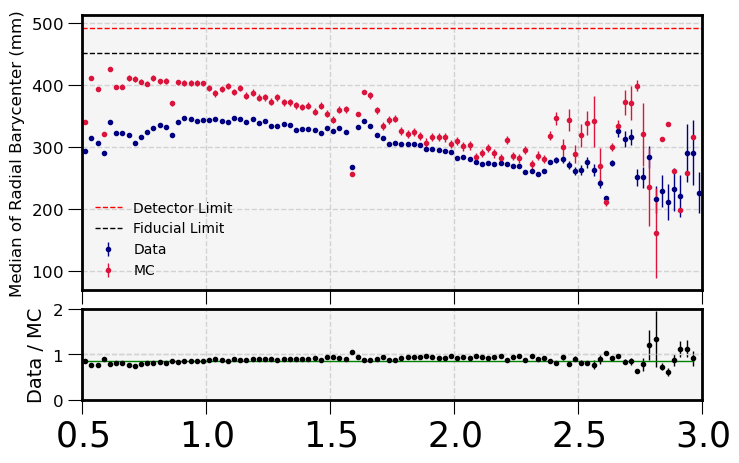

In [73]:
# Plotting configuration
fig = plt.figure(figsize=(8, 5))
# Subdivided plot: main panel and ratio panel (data/MC)
outer_gs = gridspec.GridSpec(1, 1, figure=fig)
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0], height_ratios=[3, 1], hspace=0.1)
ax_main  = fig.add_subplot(inner_gs[0])
ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

# Retrieve information
data_cv = TRACKS_INFO['data']['rad_median']['cv'];     data_err = TRACKS_INFO['data']['rad_median']['err']
mc_cv   = TRACKS_INFO['mc']['rad_median']['cv'];       mc_err   = TRACKS_INFO['mc']['rad_median']['err']

# ===============================
# --- MAIN PANEL (Upper Plot) ---
# ===============================
# Data
ax_main.errorbar(GLOBAL_CENTERS, data_cv, yerr=data_err, fmt='o', color='navy', 
                    markersize=3, elinewidth=1.0, label='Data')
# Simulations
ax_main.errorbar(GLOBAL_CENTERS, mc_cv, yerr=mc_err, fmt='o', color='crimson',
                    markersize=3, elinewidth=1.0, label='MC')
# Reference line
ax_main.axhline(crudo.pt.N100_rad, color='red', ls='--', lw=1.0, label='Detector Limit')
ax_main.axhline(R_UP, color='black', ls='--', lw=1.0, label='Fiducial Limit')

# --- Styling --- #
ax_main.set_ylabel("Median of Radial Barycenter (mm)", fontsize=12)
ax_main.set_xlim(0.5, 3.0)
ax_main.set_xticks(np.arange(0.5, 3.5, 0.5))
ax_main.tick_params(axis='y', labelsize=12)
ax_main.grid(True)
ax_main.legend(loc='lower left', fontsize=10, facecolor='none')
ax_main.set_facecolor("whitesmoke")
# Hide the x-tick labels for the main plot because they are shared with the ratio plot
plt.setp(ax_main.get_xticklabels(), visible=False)

# ================================
# --- RATIO PANEL (Lower Plot) ---
# ================================
ratio_cv, ratio_err  = np.zeros_like(data_cv), np.zeros_like(data_err)
valid_mask = (mc_cv > 0) & (data_cv > 0)      # To avoid divisions by zero

# Ratio: Data / MC
ratio_cv[valid_mask]  = data_cv[valid_mask] / mc_cv[valid_mask]
ratio_err[valid_mask] = ratio_cv[valid_mask] * np.sqrt((data_err[valid_mask] / data_cv[valid_mask])**2 
                                                        + (mc_err[valid_mask] / mc_cv[valid_mask])**2)

# --- Linear Fit --- #
# Define the cost function + initial guess
least_squares = LeastSquares(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], ratio_err[valid_mask], const_func)
init_guess = [ratio_cv[valid_mask].min()]

# Define the Minuit object
m = Minuit(least_squares, *init_guess)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Results
popt = m.values;  perr = m.errors
print(f"  Data/MC ratio: {popt[0]:.4f} ± {perr[0]:.4f}")

# Reduced chi-square
chi2 = m.fval
ndof = len(GLOBAL_CENTERS[valid_mask]) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)
print(f"  χ² / ndof = {chi2 / ndof:.2f}")
print(f"  p-value = {p_value:.2f}\n")

# --- PLotting --- #
# Ratio
ax_ratio.errorbar(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], yerr=ratio_err[valid_mask],
                    fmt='o', color='black', markersize=3, elinewidth=1.0)
# Fit
y_fit = const_func(GLOBAL_CENTERS[valid_mask], *popt)
ax_ratio.plot(GLOBAL_CENTERS[valid_mask], y_fit, color='green', lw=1.0)
# Reference line
ax_ratio.axhline(1.0, color='lightgray', ls='--', lw=1.0)

# --- Styling --- #
ax_ratio.set_ylabel("Data / MC", fontsize=14)
ax_ratio.set_ylim(0, 2)
ax_ratio.tick_params(axis='y', labelsize=12)
ax_ratio.grid(True)
ax_ratio.set_facecolor("whitesmoke")

plt.show()

#### Efficiency Plot

Ok, so let's see now how is the behaviour of the fiducial selection in different radial regions of the detector (every ~125 nm).
<br>
__NOTE: Important!__ use the ANA_INFO dictionary.

In [123]:
ANA_INFO['data'].keys()

dict_keys(['groupers', 'he_scale', 'df_summary', 'df_processed', 'df_reco', 'df_inclusive', 'df_fiducial', 'df_strack'])

In [94]:
# Preliminary information
cutflow_stages = [ ('df_inclusive', 'df_fiducial') ]
rad_limit = [0, 100, 200, 300, 400, R_UP, 500]

# Vectorized efficiency function
vec_efficiency = np.vectorize(crudo.ff.compute_efficiency)

for ana_type in ANA_OPTIONS: 

    print(f"Processing {ana_type.upper()}:")

    for stage_prior, stage_post in cutflow_stages:

        label = stage_post.split('_')[-1] + '_radial'
        print(f"  Calculating efficiency for {label} selection...")

        # Dataframe
        df_prior = ANA_INFO[ana_type][stage_prior].copy()
        df_post  = ANA_INFO[ana_type][stage_post].copy()

        # Compute R_bary for each stage
        df_prior['R_bary'] = np.sqrt(df_prior['X_bary']**2 + df_prior['Y_bary']**2)
        df_post['R_bary']  = np.sqrt(df_post['X_bary']**2 + df_post['Y_bary']**2)

        for i in range(len(rad_limit) - 1):

            lower_edge = rad_limit[i]
            upper_edge = rad_limit[i + 1]
            label_rad = f"[{lower_edge}, {upper_edge})"
            print(f"    Radial Bin: {label_rad} mm")

            # Select events within the radial bin
            df_prior_rad = df_prior[(df_prior['R_bary'] >= lower_edge) & (df_prior['R_bary'] < upper_edge)].copy()
            df_post_rad  = df_post[(df_post['R_bary'] >= lower_edge) & (df_post['R_bary'] < upper_edge)].copy()

            # Select events within the energy range
            prior_energies = df_prior_rad.groupby('global_event')['E_final'].first().reset_index(drop=True)
            post_energies  = df_post_rad.groupby('global_event')['E_final'].first().reset_index(drop=True)

            # Histograms
            prior_counts, _ = np.histogram(prior_energies, bins=GLOBAL_EDGES)
            post_counts, _  = np.histogram(post_energies, bins=GLOBAL_EDGES)

            # Ensure post-cut counts are not less than prior counts
            if np.any(post_counts > prior_counts):
                raise ValueError("post counts cannot exceed prior counts. Please check the data for inconsistencies.")

            eff_cv, eff_err = vec_efficiency(prior_counts, post_counts)

            # Ensure the dictionary for the label is initialized
            if label not in ANA_INFO[ana_type]:
                ANA_INFO[ana_type][label] = {}
            if label_rad not in ANA_INFO[ana_type][label]:
                ANA_INFO[ana_type][label][label_rad] = {}

            # Store information
            ANA_INFO[ana_type][label][label_rad]['eff_cv']  = eff_cv
            ANA_INFO[ana_type][label][label_rad]['eff_err'] = eff_err

            print(f"     {stage_prior}: {prior_counts.sum()} events")
            print(f"     {stage_post} : {post_counts.sum()} events")

Processing DATA:
  Calculating efficiency for fiducial_radial selection...
    Radial Bin: [0, 100) mm
     df_inclusive: 13065 events
     df_fiducial : 11175 events
    Radial Bin: [100, 200) mm
     df_inclusive: 39566 events
     df_fiducial : 33463 events
    Radial Bin: [200, 300) mm
     df_inclusive: 66930 events
     df_fiducial : 52162 events
    Radial Bin: [300, 400) mm
     df_inclusive: 91889 events
     df_fiducial : 29142 events
    Radial Bin: [400, 451.65) mm
     df_inclusive: 42500 events
     df_fiducial : 0 events
    Radial Bin: [451.65, 500) mm
     df_inclusive: 1046 events
     df_fiducial : 0 events
Processing MC:
  Calculating efficiency for fiducial_radial selection...
    Radial Bin: [0, 100) mm
     df_inclusive: 2211 events
     df_fiducial : 1984 events
    Radial Bin: [100, 200) mm
     df_inclusive: 6723 events
     df_fiducial : 5986 events
    Radial Bin: [200, 300) mm
     df_inclusive: 11749 events
     df_fiducial : 9928 events
    Radial Bin: [3

In [92]:
del ANA_INFO['data']['fiducial_radial']
del ANA_INFO['mc']['fiducial_radial']

Generating Plot for Radial: [0, 100) mm
  Data/MC ratio: 0.9297 ± 0.0063
  χ² / ndof = 1.50
  p-value = 0.00

Generating Plot for Radial: [100, 200) mm
  Data/MC ratio: 0.9579 ± 0.0042
  χ² / ndof = 2.19
  p-value = 0.00

Generating Plot for Radial: [200, 300) mm
  Data/MC ratio: 0.9425 ± 0.0033
  χ² / ndof = 2.95
  p-value = 0.00

Generating Plot for Radial: [300, 400) mm
  Data/MC ratio: 0.6904 ± 0.0050
  χ² / ndof = 4.35
  p-value = 0.00

Generating Plot for Radial: [400, 451.65) mm
  Data/MC ratio: 2.0000 ± 0.0000
  χ² / ndof = -0.00
  p-value = nan

Generating Plot for Radial: [451.65, 500) mm
  Data/MC ratio: 2.0000 ± 0.0000
  χ² / ndof = -0.00
  p-value = nan



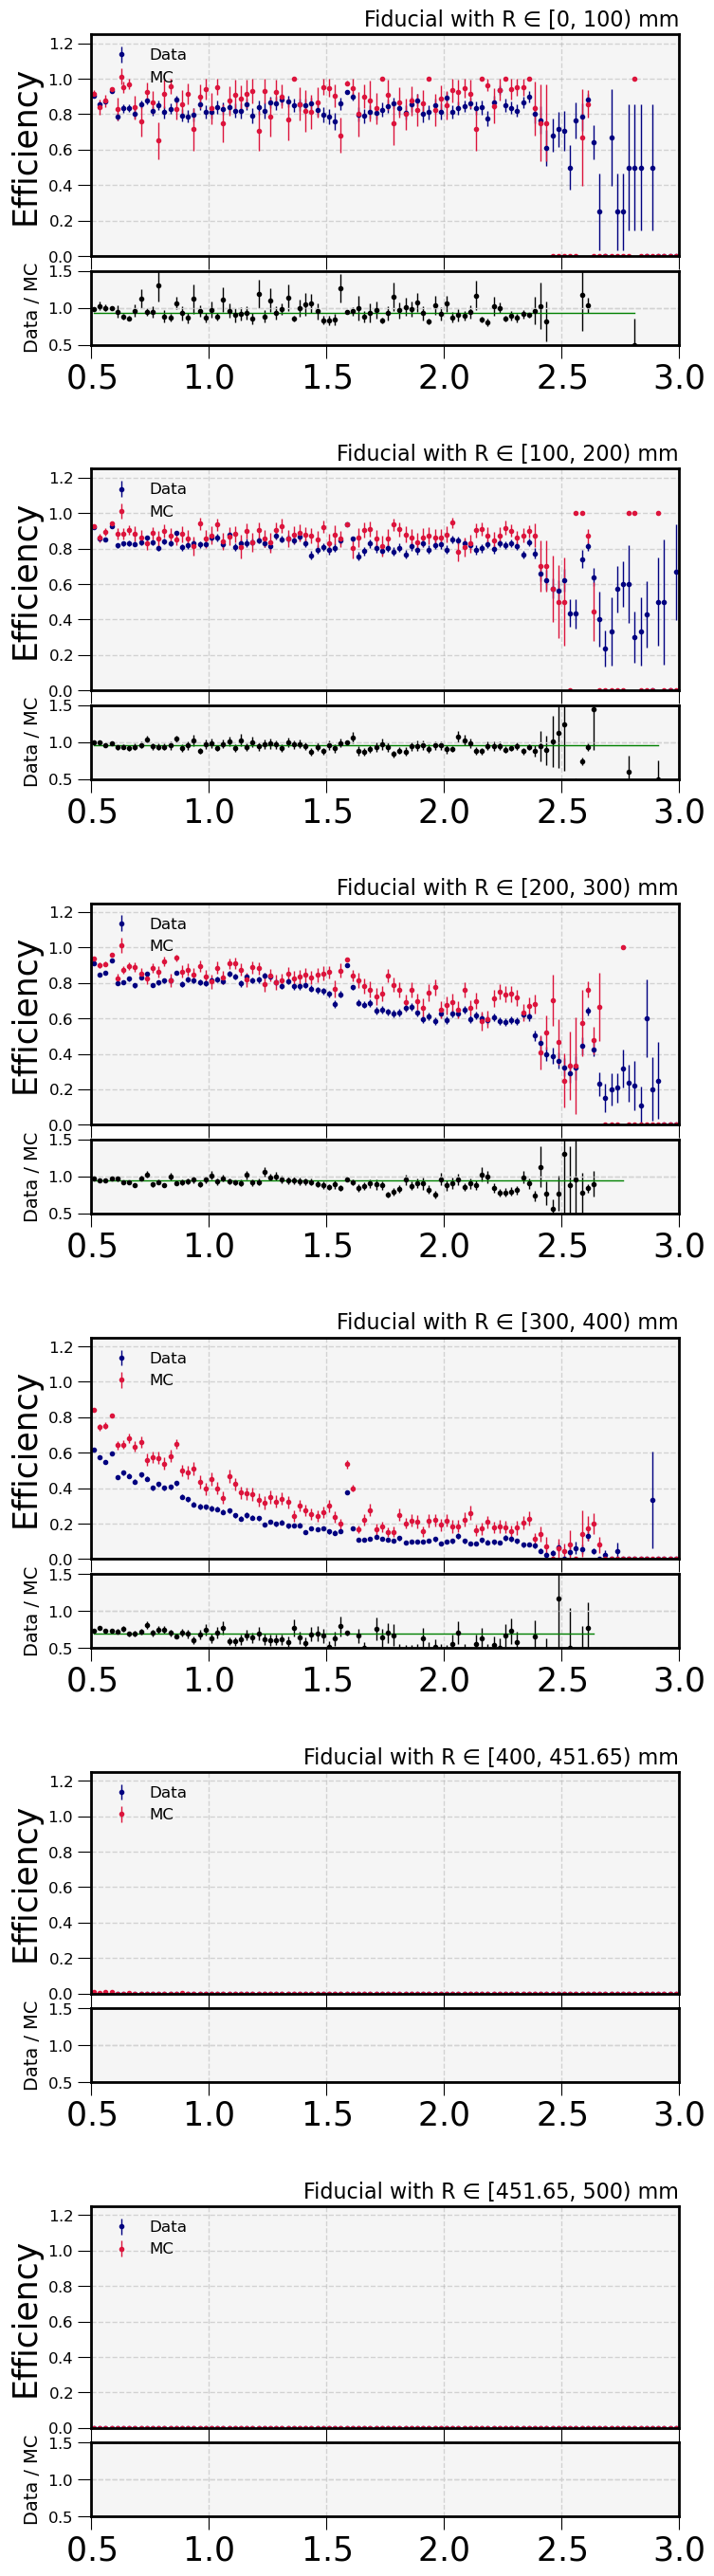

In [103]:
def const_func(x, a):
    return crudo.ff.linear_func(x, 0, a)

# Plotting configuration
fig = plt.figure(figsize=(8, 5*len(rad_limit)-1))
outer_gs = gridspec.GridSpec(len(rad_limit)-1, 1, figure=fig, hspace=0.4)

for row_idx, rad_name in enumerate(ANA_INFO['data']['fiducial_radial'].keys()):

    print(f"Generating Plot for Radial: {rad_name} mm")

    # Subdivided plot: main panel (efficiency) and ratio panel (data/MC)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.1)   
    ax_main  = fig.add_subplot(inner_gs[0])
    ax_ratio = fig.add_subplot(inner_gs[1], sharex=ax_main)

    # Retrieve information
    data_eff = ANA_INFO['data']['fiducial_radial'][rad_name]['eff_cv'];     data_err = ANA_INFO['data']['fiducial_radial'][rad_name]['eff_err']
    mc_eff   = ANA_INFO['mc']['fiducial_radial'][rad_name]['eff_cv'];       mc_err   = ANA_INFO['mc']['fiducial_radial'][rad_name]['eff_err']

    # ===============================
    # --- MAIN PANEL (Upper Plot) ---
    # ===============================
    # Data
    ax_main.errorbar(GLOBAL_CENTERS, data_eff, yerr=data_err, fmt='o', color='navy', 
                    markersize=3, elinewidth=1.0, label='Data')
    # Simulations
    ax_main.errorbar(GLOBAL_CENTERS, mc_eff, yerr=mc_err, fmt='o', color='crimson',
                    markersize=3, elinewidth=1.0, label='MC')

    # --- Styling --- #
    ax_main.set_title(f"Fiducial with R ∈ {rad_name} mm", fontsize=16, loc='right')
    ax_main.set_ylabel("Efficiency")
    ax_main.set_xlim(0.5, 3.0)
    ax_main.set_ylim(0, 1.25)
    ax_main.tick_params(axis='y', labelsize=12)
    ax_main.grid(True)
    ax_main.legend(loc='upper left', fontsize=12, facecolor='none')
    ax_main.set_facecolor("whitesmoke")
    # Hide the x-tick labels for the main plot because they are shared with the ratio plot
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # # ================================
    # # --- RATIO PANEL (Lower Plot) ---
    # # ================================
    ratio_cv, ratio_err  = np.zeros_like(data_eff), np.zeros_like(data_eff)
    valid_mask = (mc_eff > 0) & (data_eff > 0)      # To avoid divisions by zero
    
    # Ratio: Data / MC
    ratio_cv[valid_mask]  = data_eff[valid_mask] / mc_eff[valid_mask]
    ratio_err[valid_mask] = ratio_cv[valid_mask] * np.sqrt((data_err[valid_mask] / data_eff[valid_mask])**2 
                                                            + (mc_err[valid_mask] / mc_eff[valid_mask])**2)

    # --- Linear Fit --- #
    # Define the cost function + initial guess
    least_squares = LeastSquares(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], ratio_err[valid_mask], const_func)
    init_guess = [ratio_cv[valid_mask].min() if len(ratio_cv[valid_mask]) > 0 else 2.0]

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"  Data/MC ratio: {popt[0]:.4f} ± {perr[0]:.4f}")

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(GLOBAL_CENTERS[valid_mask]) - m.nfit
    p_value = scipy.stats.chi2.sf(chi2, ndof)
    print(f"  χ² / ndof = {chi2 / ndof:.2f}")
    print(f"  p-value = {p_value:.2f}\n")

    # --- PLotting --- #
    # Ratio
    ax_ratio.errorbar(GLOBAL_CENTERS[valid_mask], ratio_cv[valid_mask], yerr=ratio_err[valid_mask],
                    fmt='o', color='black', markersize=3, elinewidth=1.0)
    # Fit
    y_fit = const_func(GLOBAL_CENTERS[valid_mask], *popt)
    ax_ratio.plot(GLOBAL_CENTERS[valid_mask], y_fit, color='green', lw=1.0)
    # Reference line
    ax_ratio.axhline(1.0, color='lightgray', ls='--', lw=1.0)

    # --- Styling --- #
    ax_ratio.set_ylabel("Data / MC", fontsize=14)
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.tick_params(axis='y', labelsize=12)
    ax_ratio.grid(True)
    ax_ratio.set_facecolor("whitesmoke")
    
    # Only show the X-axis label on the very bottom subplot of the entire figure
    if row_idx == len(rad_limit) - 1:
        ax_ratio.set_xlabel("Energy (MeV)")

plt.show()